## Projeto Eletromagnetismo e Ondulatória - Grupo 9

## Produto: Conjunto mouse/mousepad em que mousepad carrega mouse por indução eletromagnética

### Modelo elétrico: 
![image info](Circuito.jpeg)

### Simualação do Modelo Elétrico para diversas frequências, capacitâncias e indutâncias

### Imports

In [165]:
from cmath import *
from numpy import linalg
import numpy as np
import matplotlib.pyplot as plt

### Definição Valores

In [166]:
Rc = 5 #simplificação -> chute
Rdc = 0.2 #simplificação -> chute  
k = 0.2 #fator de acoplamento -> chute
Uf = 9 #eficaz -> chute

lista_freq = np.arange(0,100e3,10)
lista_capac = [150e-9, 0.1e-6, 0.47e-6, 1e-6, 4.7e-6]
colors = ['b','g','r','c','m']

### Funções úteis

In [167]:
def calcula_rendimento_saida_serie(Uf, Rc, C, L, R, w, k) -> tuple:
    Uf = Uf
    XRc = Rc
    XR = R
    XC = 1/((w*C)*1j)
    XL = (w*L)*1j
    XM = k*XL

    Z=np.array([[XR+XL+XC, -XM],[-XM, XL+XR+XRc+XC]])
    V=np.array([Uf,0])
    i=np.dot(linalg.inv(Z),V)

    i1, i2 = i[0], i[1]

    v2_s = Rc*i2
    Psaida = np.real((v2_s*np.conj(i2))/2)
    Pentrada = np.real((Uf*np.conj(i1))/2)
    rendimento = Psaida/Pentrada

    return abs(v2_s), rendimento*100

def calcula_rendimento_saida_paralelo(Uf, Rc, C, L, R, w, k) -> tuple:
    Uf = Uf
    XRc = Rc
    XR = R
    XC = 1/((w*C)*1j)
    XL = (w*L)*1j
    XM = k*XL
    Zcarga = ((XRc*XC)/(XRc+XC))

    Z=np.array([[XR+XL+XC, -XM],[-XM, XL+XR+Zcarga]])
    V=np.array([Uf,0])
    i=np.dot(linalg.inv(Z),V)

    i1, i2 = i[0], i[1]

    v2_p = Zcarga*i2
    ic = (XC*i2)/(XRc+XC)
    Psaida = np.real((v2_p*np.conj(ic))/2)
    Pentrada = np.real((Uf*np.conj(i1))/2)
    rendimento = Psaida/Pentrada

    return abs(v2_p), rendimento*100

def calcula_rendimento_saida_validacao(w, rc, k) -> tuple:
    XR1 = Rint1
    XR2 = Rint2
    XC = 1/((w*C)*1j)
    XL1 = (w*L1)*1j
    XL2 = (w*L2)*1j
    XM = k*((XL1*XL2)**0.5)
    XRc = rc

    Z=np.array([[XR1+XL1+XC, -XM],[-XM, XL2+XR2+XRc+XC]])
    V=np.array([Uf,0])
    i=np.dot(linalg.inv(Z),V)

    i1, i2 = i[0], i[1]

    v2_s = XRc*i2
    Psaida = np.real((v2_s*np.conj(i2))/2)
    Pentrada = np.real((Uf*np.conj(i1))/2)
    rendimento = Psaida/Pentrada

    return abs(v2_s), rendimento*100

def plot_serie(cap_freq_vs_rend_s, cap_freq_vs_saida_s) -> None:
    fig, ax1 = plt.subplots(figsize=(20,14))

    ax1.set_xlabel('Frequências')
    ax1.set_ylabel('Rendimento %')
    ax1.tick_params(axis='y')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Saída V2 pico')
    ax2.tick_params(axis='y')

    for i, (c, rendimento) in enumerate(cap_freq_vs_rend_s.items()):
        ax1.plot(lista_freq, rendimento, color=colors[i], label=f'Rendimento para capacitância de: {c}F', linestyle=':')
        
        ax2.plot(lista_freq, list(cap_freq_vs_saida_s.values())[i], color=colors[i], label=f'Saída para capacitância de: {c}F', linestyle='-')

    plt.title('Frequência VS Rendimento & Saída ---- Em série')

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

def plot_paralelo(cap_freq_vs_rend_p, cap_freq_vs_saida_p) -> None:
    fig, ax1 = plt.subplots(figsize=(20,14))

    ax1.set_xlabel('Frequências')
    ax1.set_ylabel('Rendimento %')
    ax1.tick_params(axis='y')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Saída V2 pico')
    ax2.tick_params(axis='y')

    for i, (c, rendimento) in enumerate(cap_freq_vs_rend_p.items()):
        ax1.plot(lista_freq, rendimento, color=colors[i], label=f'Rendimento para capacitância de: {c}F', linestyle=':')
        
        ax2.plot(lista_freq, list(cap_freq_vs_saida_p.values())[i], color=colors[i], label=f'Saída para capacitância de: {c}F', linestyle='-')

    plt.title('Frequência VS Rendimento & Saída ---- Em paralelo')

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

def plot_validacao(rc_k_vs_rend_s, rc_k_vs_saida_s) -> None:
    fig, ax1 = plt.subplots(figsize=(20,14))

    ax1.set_xlabel('K')
    ax1.set_ylabel('Rendimento %')
    ax1.tick_params(axis='y')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Saída V2 pico')
    ax2.tick_params(axis='y')

    for i, (rc, rendimento) in enumerate(rc_k_vs_rend_s.items()):
        ax1.plot(lista_k, rendimento, color=colors[i], label=f'Rendimento para Rc de: {rc} Ohms', linestyle=':')
        
        ax2.plot(lista_k, list(rc_k_vs_saida_s.values())[i], color=colors[i], label=f'Saída para Rc de: {rc} Ohms', linestyle='-')

    plt.title('Fator de Acoplamento (K) VS Rendimento & Saída ---- Em série')

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

### Função para simular

In [168]:
def calculate(lista_capac, lista_freq) -> tuple:
    cap_freq_vs_rend_s = {}
    cap_freq_vs_saida_s = {}

    cap_freq_vs_rend_p = {}
    cap_freq_vs_saida_p = {}

    for C in lista_capac:
        rend_aux_s = []
        saida_aux_s = []
        rend_aux_p = []
        saida_aux_p = []
        
        for fr in lista_freq:
            w = 2*pi*fr
            L = ((1/(2*pi*fr))**2)*(1/C)
            R = Rdc + (Rdc/(100e3))*fr

            v2_s, rendimento_s = calcula_rendimento_saida_serie(Uf, Rc, C, L, R, w, k)
            rend_aux_s.append(rendimento_s)
            saida_aux_s.append(v2_s)

            v2_p, rendimento_p = calcula_rendimento_saida_paralelo(Uf, Rc, C, L, R, w, k)
            rend_aux_p.append(rendimento_p)
            saida_aux_p.append(v2_p)

            if fr == 51000 and C == 150e-9:
                print(f'Saída de {v2_s} e eficiência de {rendimento_s} para frequência de 51000 e capacitância de 150nF')
            
        cap_freq_vs_rend_s[C] = rend_aux_s
        cap_freq_vs_saida_s[C] = saida_aux_s

        cap_freq_vs_rend_p[C] = rend_aux_p
        cap_freq_vs_saida_p[C] = saida_aux_p


    return cap_freq_vs_rend_s, cap_freq_vs_saida_s, cap_freq_vs_rend_p, cap_freq_vs_saida_p


### Plotando

/tmp/ipykernel_23746/1475351777.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  L = ((1/(2*pi*fr))**2)*(1/C)
/tmp/ipykernel_23746/3989915014.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  XC = 1/((w*C)*1j)
/tmp/ipykernel_23746/3989915014.py:5: RuntimeWarning: invalid value encountered in scalar divide
  XC = 1/((w*C)*1j)
/tmp/ipykernel_23746/3989915014.py:6: RuntimeWarning: invalid value encountered in scalar multiply
  XL = (w*L)*1j
/tmp/ipykernel_23746/3989915014.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  XC = 1/((w*C)*1j)
/tmp/ipykernel_23746/3989915014.py:26: RuntimeWarning: invalid value encountered in scalar divide
  XC = 1/((w*C)*1j)
/tmp/ipykernel_23746/3989915014.py:27: RuntimeWarning: invalid value encountered in scalar multiply
  XL = (w*L)*1j
/tmp/ipykernel_23746/3989915014.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  Zcarga = ((XRc*XC)/(XRc+XC))
/tmp/ipykernel_23746/3989915014.py:2

Saída de 9.899391722490305 e eficiência de 86.32070309787454 para frequência de 51000 e capacitância de 150nF


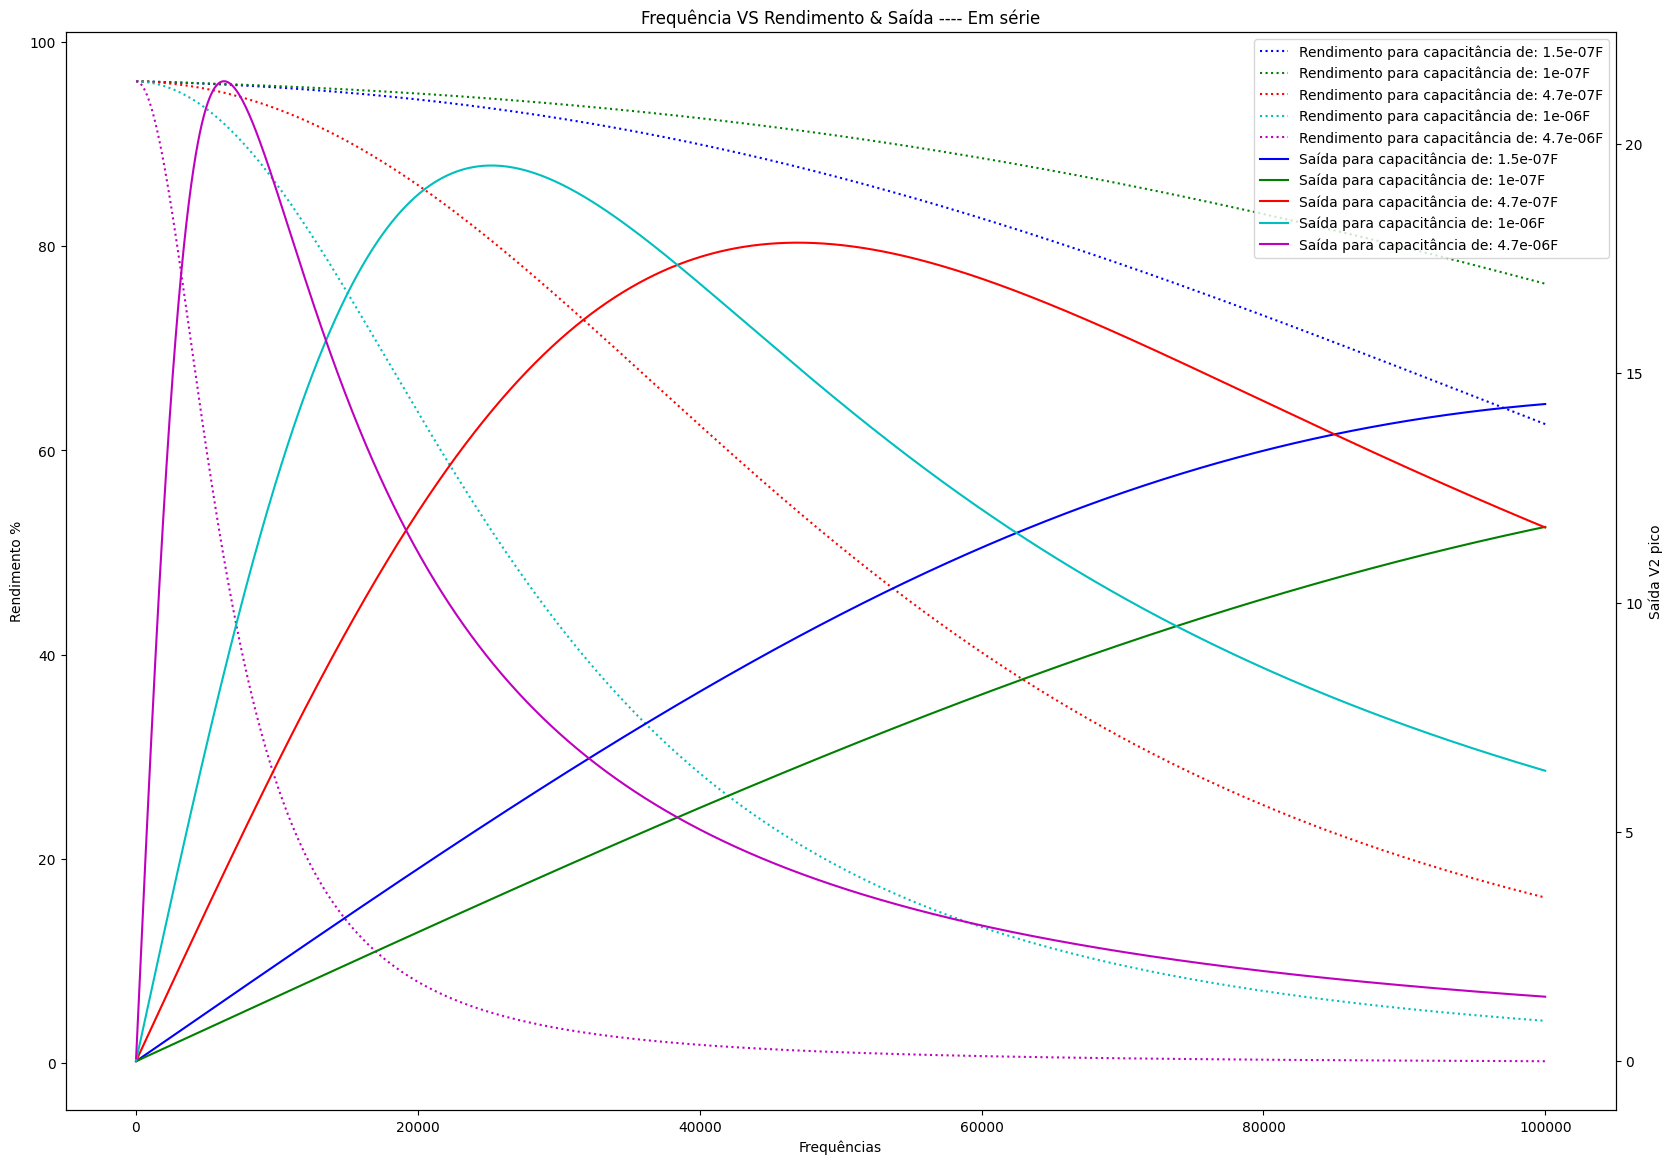

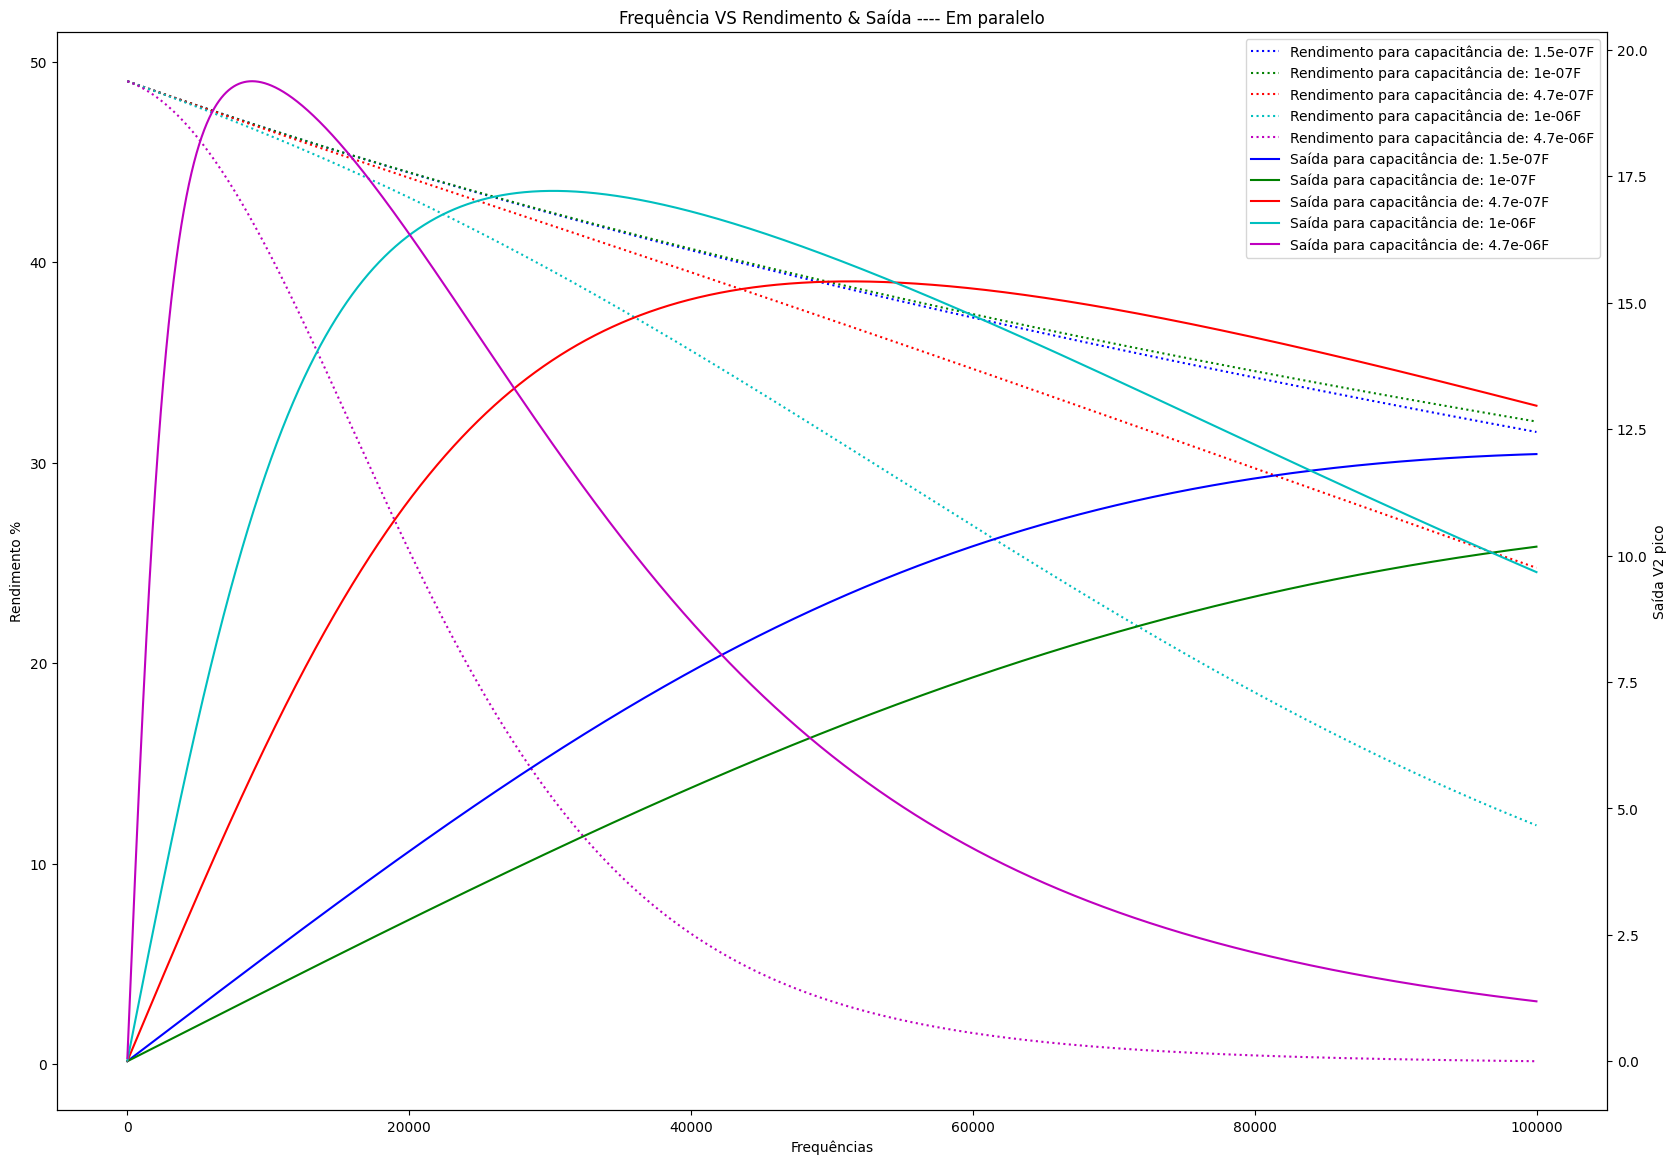

In [169]:
cap_freq_vs_rend_s, cap_freq_vs_saida_s, cap_freq_vs_rend_p, cap_freq_vs_saida_p = calculate(lista_capac, lista_freq)

plot_serie(cap_freq_vs_rend_s, cap_freq_vs_saida_s)
plot_paralelo(cap_freq_vs_rend_p, cap_freq_vs_saida_p)

plt.show()

### Escolhendo a cacitância de 150nF e frequência de 51.000 Hz. Assim, determina-se uma indutância de 65nH para ambas as bobinas e realizamos mais uma simulação com os valores reais para uma gama de cargas conhecidas

In [170]:
C = 150e-9
L1 = 65.5e-6
L2 = 64.75e-6
Rint1 = 651.5e-3
Rint2 = 616.9e-3
Uf = 9*(2/np.pi) #eficaz

lista_k = np.arange(0,0.5,0.01)
colors = ['b','g','r','c','m', 'royalblue', 'slategrey', 'plum']
lista_rc = [5, 10, 15, 20, 25, 30, 35, 40]

# colors = ['orange']
# lista_rc = [100]

## Função para validação da frequência escolhida

In [171]:
#Retorna a melhor frequência para cada rc, a meta é que a frequência ideal seja próxima a frequência escolhida, fato que se mostra verdade
def freq_maior_pico() -> dict:

    rc_freq_vs_rend_s = {}
    rc_freq_vs_saida_s = {}
    freq_maior_pico = {}

    freqs = np.arange(0,100e3,10)
    k = 0.15 #Fixando

    for rc in lista_rc:
        rend_aux_s = []
        saida_aux_s = []

        for fr in freqs:
            w = 2*pi*fr

            v2_s, rendimento_s = calcula_rendimento_saida_validacao(w, rc, k)
            rend_aux_s.append(rendimento_s)
            saida_aux_s.append(v2_s)
            
        rc_freq_vs_rend_s[rc] = rend_aux_s
        rc_freq_vs_saida_s[rc] = saida_aux_s

        i = 0
        maior = 0
        for saida in saida_aux_s:
            if saida > maior:
                maior = saida
                index = i
            i += 1

        maior_freq = freqs[index]
        freq_maior_pico[rc] = maior_freq

    return freq_maior_pico

### Rodando segunda simulação

In [172]:
def calculate2() -> tuple:
    rc_k_vs_rend_s = {}
    rc_k_vs_saida_s = {}

    for rc in lista_rc:
        rend_aux_s = []
        saida_aux_s = []
        
        melhor_freq = freq_maior_pico()
        freq1 = melhor_freq[rc]
        w1 = 2*np.pi*freq1

        for k in lista_k:
            v2_s, rendimento_s = calcula_rendimento_saida_validacao(w1, rc, k)
            rend_aux_s.append(rendimento_s)
            saida_aux_s.append(v2_s)

            
        rc_k_vs_rend_s[rc] = rend_aux_s
        rc_k_vs_saida_s[rc] = saida_aux_s

    return rc_k_vs_rend_s, rc_k_vs_saida_s

## Plotando

/tmp/ipykernel_23746/3989915014.py:48: RuntimeWarning: divide by zero encountered in scalar divide
  XC = 1/((w*C)*1j)
/tmp/ipykernel_23746/3989915014.py:48: RuntimeWarning: invalid value encountered in scalar divide
  XC = 1/((w*C)*1j)


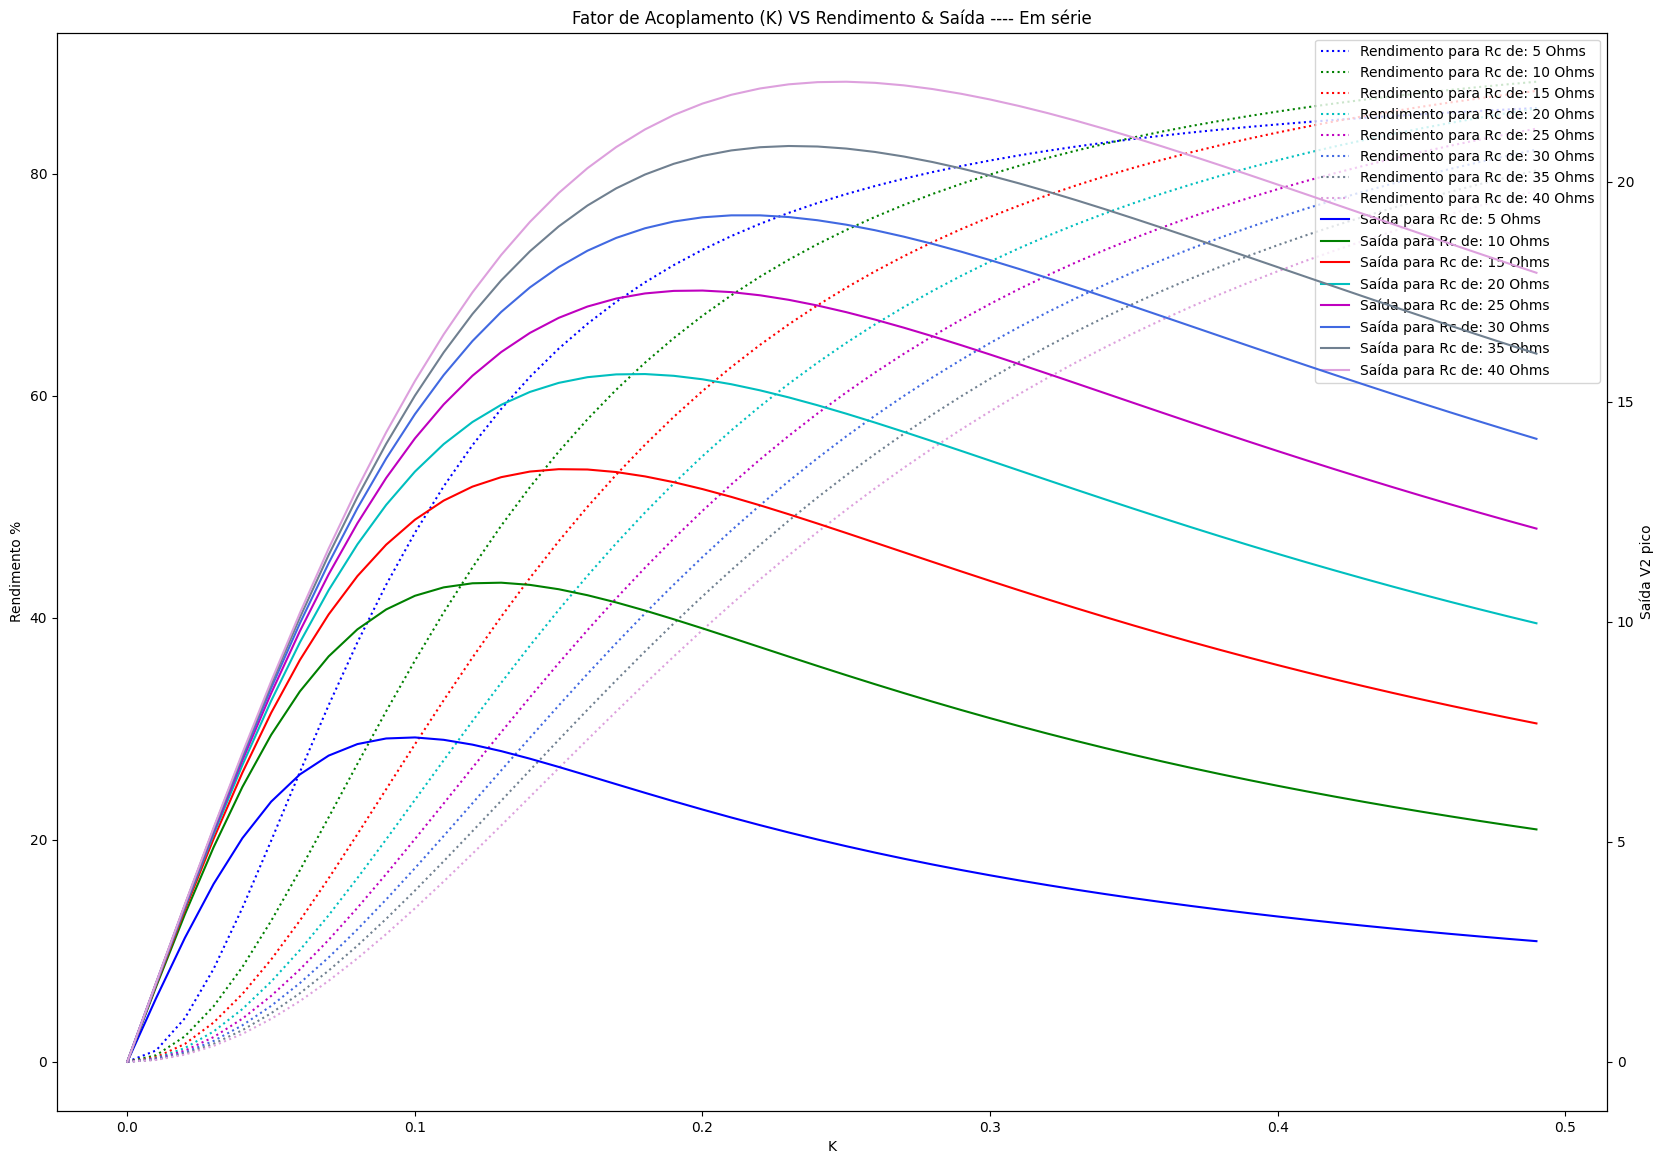

In [173]:
rc_k_vs_rend_s, rc_k_vs_saida_s = calculate2()

plot_validacao(rc_k_vs_rend_s, rc_k_vs_saida_s)

plt.show()